# Introduction

This notebook runs a simple benchmark of [GPU-accelerated HDBSCAN](https://docs.rapids.ai/api/cuml/nightly/api/generated/cuml.cluster.hdbscan.hdbscan/).

# Preparation

## Imports

In [9]:
from cuml.cluster import HDBSCAN
from scipy.cluster.hierarchy import to_tree
from seaborn import move_legend, relplot
from time import time
from tqdm.notebook import trange
import matplotlib.pyplot as plt
import polars as pl

## Constants

### Number of `DataFrame` Rows and Columns

In [2]:
NUM_ROWS = [10_000, 20_000, 40_000, 100_000, 200_000, 400_000, 1_000_000]
NUM_COLS = [10, 100]

### Number of Replicates per `DataFrame` Dimensions

In [3]:
NUM_REPS = 5

## Functions

### Compute HDBSCAN Clustering Tree

In [4]:
def compute_hdbscan_tree(df, label_col=None):
    labels = list(range(df.height)) if label_col is None else df.get_column(label_col).to_list()
    model = HDBSCAN(min_cluster_size=2, min_samples=1)
    model.fit(df.select(pl.selectors.numeric()).to_numpy())
    linkage_matrix = model.single_linkage_tree_.to_numpy()
    root, nodes = to_tree(linkage_matrix, rd=True)
    for i in range(len(labels)):
        nodes[i].label = labels[i]
    return linkage_matrix, root, nodes

### Compute Number of Clusters vs. Height (i.e., distance from leaves)

In [5]:
def compute_clusters_vs_height(nodes, include_singletons=False):
    num_clusters = dict()
    curr_num_clusters = 0
    for node in sorted(nodes, key=lambda x:x.dist):
        if node.is_leaf():
            if include_singletons:
                curr_num_clusters += 1
        else: # internal node
            if include_singletons:
                curr_num_clusters -= 1
            else:
                num_leaf_children = int(node.left.is_leaf()) + int(node.right.is_leaf())
                if num_leaf_children == 0:
                    curr_num_clusters -= 1
                elif num_leaf_children == 2:
                    curr_num_clusters += 1
        num_clusters[node.dist] = curr_num_clusters
    return num_clusters

### Generate Random `DataFrame`

In [6]:
def generate_random_dataframe(num_rows, num_cols):
    return pl.select(pl.lit(None).repeat_by(num_rows).alias("index")).select([pl.lit(0).sample(n=num_rows, with_replacement=True).alias(f"col_{i}") for i in range(num_cols)])

# Benchmark

## Run Experiment

In [7]:
x = list(); y = list(); h = list()
for num_rows in NUM_ROWS:
    for num_cols in NUM_COLS:
        for rep in trange(NUM_REPS, desc=f"{num_rows:,} x {num_cols:,}"):
            df = generate_random_dataframe(num_rows, num_cols)
            start_time = time()
            linkage_matrix, root, nodes = compute_hdbscan_tree(df)
            end_time = time()
            x.append(num_rows); y.append(end_time-start_time); h.append(num_cols)

10,000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

10,000 x 100:   0%|          | 0/5 [00:00<?, ?it/s]

20,000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

20,000 x 100:   0%|          | 0/5 [00:00<?, ?it/s]

40,000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

...

200,000 x 100:   0%|          | 0/5 [00:00<?, ?it/s]

400,000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

400,000 x 100:   0%|          | 0/5 [00:00<?, ?it/s]

1,000,000 x 10:   0%|          | 0/5 [00:00<?, ?it/s]

1,000,000 x 100:   0%|          | 0/5 [00:00<?, ?it/s]

## Plot Results

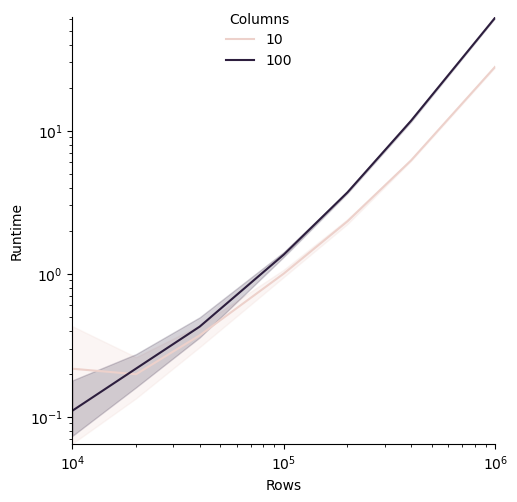

In [12]:
g = relplot(x=x, y=y, hue=h, kind='line')
g.set_axis_labels("Rows", "Runtime")
g.legend.set_title("Columns")
g.set(
    xlim=(min(x), max(x)),
    ylim=(min(y), max(y)),
    xscale="log",
    yscale="log",
)
move_legend(g, loc="upper center")
plt.savefig("hdbscan_benchmark.pdf", bbox_inches="tight")